# Preparation

## Import

In [9]:
# Make the `utils` helper package importable regardless of CWD.
# Layout: bakeoff/scripts/analysis/utils/{parser,util}.py
import sys
from pathlib import Path as _PathBootstrap
_HERE = _PathBootstrap.cwd()
for _cand in [_HERE / 'scripts' / 'analysis',  # CWD = bakeoff/
              _HERE,                            # CWD = bakeoff/scripts/analysis/
              _HERE / 'bakeoff' / 'scripts' / 'analysis']:
    if (_cand / 'utils' / '__init__.py').exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand))
        break

import os
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from scipy.spatial.distance import braycurtis, cosine
from scipy.cluster.hierarchy import linkage

from utils.util import _clean_name

## Configuration

In [ ]:
# Global inputs (DYN heatmap case study, cache-driven)
# Reads from the cohort cache produced by:
#   bakeoff/scripts/analysis/dyn_prep.py
# Run that first; this notebook only consumes the cached TSVs.

from pathlib import Path
import os
import matplotlib.pyplot as plt

# NOTE: heatmap uses MIN_ABUNDANCE (percent units)
MIN_ABUNDANCE = 0.1   # e.g. 0.1 means 0.1% minimum to keep taxa in heatmaps/tables
RANKS = ["species", "genus"]

# Plot-only convenience: if True, load previously saved abundance matrices
# from OUTPUT_TABLE instead of rebuilding them.
LOAD_SAVED_ABUNDANCE_MATRICES = False

# Dataset selector
# Choose one "case sample" key (sample × platform combination) to plot.
DATASET = "dyn_0004_d10_pacbio"   # e.g. dyn_0004_d10_pacbio | dyn_0004_d10_ont

# ONT kit selector (only used if PLATFORM is "ont")
ONT_KIT = "qiagen"             # "qiagen" or "zymo"

# Registry: dataset -> platform + sample_id
DATASETS = {
    "dyn_0004_d10_illumina": {"platform": "illumina", "sample_id": "DYN_0004_D10"},
    "dyn_0004_d10_pacbio":   {"platform": "pacbio",   "sample_id": "DYN_0004_D10"},
    "dyn_0004_d10_ont":      {"platform": "ont",      "sample_id": "DYN_0004_D10"},
}
if DATASET not in DATASETS:
    raise ValueError(f"Unknown DATASET='{DATASET}'. Choose from: {sorted(DATASETS)}")

PLATFORM  = DATASETS[DATASET]["platform"]
SAMPLE_ID = DATASETS[DATASET]["sample_id"]

# Map (platform, ONT_KIT) -> cohort label used in cohort-cache filenames
if PLATFORM == "ont":
    kit = ONT_KIT.lower().strip()
    if kit not in {"qiagen", "zymo"}:
        raise ValueError("ONT_KIT must be 'qiagen' or 'zymo'")
    COHORT = f"ont_{kit}"
elif PLATFORM in {"pacbio", "illumina"}:
    COHORT = PLATFORM
else:
    raise ValueError(f"Unsupported PLATFORM={PLATFORM!r}")

DATASET_LABEL = f"{COHORT}_{SAMPLE_ID}"

# Cohort cache (output of dyn_prep.py — most recent timestamped run)
from utils.alpha_div import find_latest_cohort_cache
from utils.results   import find_latest_dyn_prep_ts, save_csv, save_fig

SAVE = True
RESULTS_ROOT = Path("/home/Users/pacbio_bakeoff/bakeoff/results")
TS           = find_latest_dyn_prep_ts(RESULTS_ROOT)  # or pin: TS = "YYYYMMDD_HHMMSS"
CACHE_DIR    = find_latest_cohort_cache(RESULTS_ROOT)

def cache_tsv_path(cohort: str, tool: str, db_mode: str, rank: str) -> Path:
    """Path to the cohort cache TSV for one (cohort, tool, db_mode, rank)."""
    return CACHE_DIR / f"{cohort}_{tool}_{db_mode}_{rank}.tsv"

# Outputs land under <ts>/dyn-case-heatmap/<dataset>/threshold_<X>/{tables,figures}/
OUTPUT_DIR    = RESULTS_ROOT / TS / "dyn-case-heatmap" / DATASET / f"threshold_{MIN_ABUNDANCE}"
OUTPUT_TABLE  = OUTPUT_DIR / "tables"
OUTPUT_FIG    = OUTPUT_DIR / "figures"

# Figure parameters
FIG_DPI = 300
FIG_FORMAT = "png"

# Tool order (used for matrices, heatmaps, similarity)
TOOL_ORDER = ["Centrifuge", "Centrifuger", "Kraken2", "Ganon2", "Sourmash", "Sylph"]

# Selected tool_db (best per tool) for case study
# Dict order = plotting order later. Tool name capitalization here drives the
# downstream display order; cohort-cache files use lowercase for sourmash/sylph/
# ganon2 — we map below.
SELECTED_DB_PER_TOOL = {
    "Kraken2":     "unified",
    "Centrifuge":  "unified",
    "Centrifuger": "unified",
    "Sourmash":    "unified",
    "Sylph":       "unified",
    "Ganon2":      "unified",  # unified for every tool (Ganon2 unified rebuilt after a major bug fix)
}

# Map display-cased tool name -> cache filename token (cohort cache used this naming)
_TOOL_NAME_IN_CACHE = {
    "Kraken2":     "Kraken2",
    "Centrifuge":  "Centrifuge",
    "Centrifuger": "Centrifuger",
    "Sourmash":    "sourmash",
    "Sylph":       "sylph",
    "Ganon2":      "ganon2",
}

# Illumina consensus settings (selected tool_db only)
ILLU_CONSENSUS_ENABLED = True
ILLU_CONSENSUS_K = 3                 # ≥3 tools agree
ILLU_CONSENSUS_MIN_ABUND = MIN_ABUNDANCE
ILLU_TOOLS_SELECTED = SELECTED_DB_PER_TOOL.copy()

print(f"DATASET={DATASET}  PLATFORM={PLATFORM}  COHORT={COHORT}  SAMPLE_ID={SAMPLE_ID}")
if PLATFORM == "ont":
    print(f"ONT_KIT={ONT_KIT}")
print(f"CACHE_DIR    : {CACHE_DIR.resolve() if CACHE_DIR.exists() else '(missing — run dyn_prep.py first)'}")
print(f"Output dir   : {OUTPUT_DIR.resolve()}")

# Existence sanity for selected tool_db × rank cohort TSVs
missing = []
for tool, db_mode in SELECTED_DB_PER_TOOL.items():
    cache_tool = _TOOL_NAME_IN_CACHE[tool]
    for rank in RANKS:
        p = cache_tsv_path(COHORT, cache_tool, db_mode, rank)
        if not p.exists():
            missing.append(p)
    # illumina baseline for consensus
    for rank in RANKS:
        p = cache_tsv_path("illumina", cache_tool, db_mode, rank)
        if not p.exists():
            missing.append(p)
if missing:
    print("\n[WARN] Missing cohort-cache TSVs:")
    for p in missing[:10]:
        print("  -", p)
    if len(missing) > 10:
        print(f"  ... (+{len(missing) - 10} more)")
else:
    print("\n✓ All required cohort-cache TSVs present.")

print(f"\n✓ Configuration loaded successfully")
print(f"  - Ranks: {RANKS}")
print(f"  - MIN_ABUNDANCE={MIN_ABUNDANCE}%")


DATASET=dyn_0004_d10_ont  PLATFORM=ont  COHORT=ont_qiagen  SAMPLE_ID=DYN_0004_D10
ONT_KIT=qiagen
CACHE_DIR    : /home/Users/pacbio_bakeoff/bakeoff/results/metadata/20260531_030023/dyn-prep/tables/cohorts
Output dir   : /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1

✓ All required cohort-cache TSVs present.

✓ Configuration loaded successfully
  - Ranks: ['species', 'genus']
  - MIN_ABUNDANCE=0.1%


# Data Processing

In [11]:
# Build per-tool (key, taxid, name, abundance) tables for the selected sample
# from the cohort cache.
#   - input : CACHE_DIR / f"{COHORT}_{tool}_{db_mode}_{rank}.tsv"
#   - filter: sample_id_core == SAMPLE_ID
#   - value : norm_abund (per-rank composition, renormalized to 100 over classified taxa)
#   - key   : canonical taxid where resolved, else the name — so taxa match across tools
#             by taxid (fixes Centrifuger's '[Clostridium]_scindens' vs '[Clostridium]
#             scindens'), while unmapped taxid<=0 stay distinct by name. Displayed by name.
#   - output: all_results[rank]["tools"][tool_db] / ["tools_raw"][tool_db]

import numpy as np
import pandas as pd

# Manual taxid equivalence (Lactobacillus -> Limosilactobacillus, the 2020 split); the
# same map the mock abundance analysis uses. NOT an NCBI merged.dmp entry (1578 is not
# retired) -- retired-id canonicalization already happened upstream in dyn_prep.
SYNONYM_TAXID_MAP = {1578: 2742598}

_KEY_COLS = ["key", "taxid", "name", "abundance"]


def _load_from_cache(cohort, tool, db_mode, rank, sample_id_core):
    """Return DataFrame(key, taxid, name, abundance) for one biological sample."""
    cache_tool = _TOOL_NAME_IN_CACHE[tool]
    p = cache_tsv_path(cohort, cache_tool, db_mode, rank)
    if not p.exists():
        return pd.DataFrame(columns=_KEY_COLS)

    df = pd.read_csv(p, sep="\t", usecols=["sample_id_core", "taxid", "name", "norm_abund"])
    df = df[df["sample_id_core"].astype(str) == str(sample_id_core)]
    if df.empty:
        return pd.DataFrame(columns=_KEY_COLS)

    df = df.rename(columns={"norm_abund": "abundance"})
    df["taxid"] = pd.to_numeric(df["taxid"], errors="coerce").fillna(0).astype(int)
    df["taxid"] = df["taxid"].map(lambda t: SYNONYM_TAXID_MAP.get(t, t))
    df["name"] = df["name"].astype(str)
    df["abundance"] = pd.to_numeric(df["abundance"], errors="coerce").fillna(0.0)

    # Drop generic non-taxon rows that confuse a per-taxon view
    df = df[~df["name"].str.lower().isin(["unclassified", "root", "unknown"])].copy()

    df["key"] = np.where(df["taxid"] > 0, df["taxid"].astype(str), "name:" + df["name"])
    # Collapse duplicates on the canonical key (name variants, synonym-merged taxids)
    df = df.groupby("key", as_index=False).agg(
        taxid=("taxid", "first"), name=("name", "first"), abundance=("abundance", "sum"))
    return df[_KEY_COLS]


all_results = {}

for rank in RANKS:
    print("\n" + "=" * 60)
    print(f"ANALYZING RANK: {rank.upper()}")
    print("=" * 60)
    print(f"\nLoading from cache for {rank} (sample={SAMPLE_ID}, cohort={COHORT}):")

    tools_raw = {}
    tools_filtered = {}

    for tool, db_mode in SELECTED_DB_PER_TOOL.items():
        tool_db = f"{tool}_{db_mode}"
        df = _load_from_cache(COHORT, tool, db_mode, rank, SAMPLE_ID)

        if df.empty:
            print(f"  - {tool_db}: (no rows for {SAMPLE_ID})")
            empty = pd.DataFrame(columns=_KEY_COLS)
            tools_raw[tool_db] = empty.copy()
            tools_filtered[tool_db] = empty.copy()
            continue

        tools_raw[tool_db] = df.copy()

        if MIN_ABUNDANCE > 0:
            before = len(df)
            df_filt = df[df["abundance"] >= MIN_ABUNDANCE].reset_index(drop=True)
            print(f"  - {tool_db}: filtered {before} → {len(df_filt)} taxa (≥ {MIN_ABUNDANCE}%)")
        else:
            df_filt = df.copy()
            print(f"  - {tool_db}: {len(df_filt)} taxa (no threshold)")

        tools_filtered[tool_db] = df_filt

    all_results[rank] = {
        "tools":     {k: v.copy() for k, v in tools_filtered.items()},
        "tools_raw": {k: v.copy() for k, v in tools_raw.items()},
    }
    print(f"\nStored for rank={rank}: {len(all_results[rank]['tools'])} tool tables.")

print("\n" + "=" * 60)
print("DATA LOADING COMPLETE (cache-driven)")
print("=" * 60)



ANALYZING RANK: SPECIES

Loading from cache for species (sample=DYN_0004_D10, cohort=ont_qiagen):
  - Kraken2_unified: filtered 5846 → 43 taxa (≥ 0.1%)
  - Centrifuge_unified: filtered 10671 → 45 taxa (≥ 0.1%)
  - Centrifuger_unified: filtered 10237 → 34 taxa (≥ 0.1%)
  - Sourmash_unified: filtered 106 → 28 taxa (≥ 0.1%)
  - Sylph_unified: filtered 71 → 26 taxa (≥ 0.1%)
  - Ganon2_unified: filtered 583 → 27 taxa (≥ 0.1%)

Stored for rank=species: 6 tool tables.

ANALYZING RANK: GENUS

Loading from cache for genus (sample=DYN_0004_D10, cohort=ont_qiagen):
  - Kraken2_unified: filtered 1842 → 19 taxa (≥ 0.1%)
  - Centrifuge_unified: filtered 2394 → 29 taxa (≥ 0.1%)
  - Centrifuger_unified: filtered 2502 → 15 taxa (≥ 0.1%)
  - Sourmash_unified: filtered 61 → 14 taxa (≥ 0.1%)
  - Sylph_unified: filtered 48 → 17 taxa (≥ 0.1%)
  - Ganon2_unified: filtered 324 → 13 taxa (≥ 0.1%)

Stored for rank=genus: 6 tool tables.

DATA LOADING COMPLETE (cache-driven)


In [12]:
# BUILD ILLUMINA CONSENSUS TAXA (selected tool_db only)
#   - Source: illumina rows of the cohort cache (same SAMPLE_ID).
#   - Keyed on canonical taxid (Change 4); display name carried alongside.
#   - Output:
#       illu_consensus_taxa[rank]  = set(keys)
#       illu_support_counts[rank]  = DataFrame: key, name, support_count, supporting_tool_dbs

import pandas as pd

def build_illumina_consensus_taxa(
    sample_id_core: str,
    selected_db_per_tool: dict,
    ranks: list[str],
    k: int = 3,
    min_abund: float = 0.1,
) -> tuple[dict, dict]:
    """Compute Illumina consensus taxa sets per rank, using only selected tool_db.

    Presence definition: abundance >= min_abund (percent units). Keyed on canonical taxid.
    """
    illu_consensus_taxa: dict[str, set] = {}
    illu_support_counts: dict[str, pd.DataFrame] = {}

    for rank in ranks:
        support: dict[str, set] = {}
        key_name: dict[str, str] = {}
        parsed_any = 0

        for tool, db_mode in selected_db_per_tool.items():
            tool_db = f"{tool}_{db_mode}"
            df = _load_from_cache("illumina", tool, db_mode, rank, sample_id_core)
            if df.empty:
                print(f"[WARN] illumina cache empty for {tool_db} / {rank} / {sample_id_core}")
                continue

            parsed_any += 1
            present = df.loc[df["abundance"] >= float(min_abund)]
            for key, nm in zip(present["key"], present["name"]):
                support.setdefault(key, set()).add(tool_db)
                key_name.setdefault(key, nm)

        if parsed_any == 0:
            print(f"[WARN] No illumina cache rows parsed for rank={rank}")
            illu_consensus_taxa[rank] = set()
            illu_support_counts[rank] = pd.DataFrame(columns=["key", "name", "support_count", "supporting_tool_dbs"])
            continue

        rows = []
        for key, tdb_set in support.items():
            rows.append({
                "key":                 key,
                "name":                key_name.get(key, key),
                "support_count":       len(tdb_set),
                "supporting_tool_dbs": ",".join(sorted(tdb_set)),
            })
        counts = pd.DataFrame(rows).sort_values(["support_count", "name"], ascending=[False, True]).reset_index(drop=True)

        consensus = set(counts.loc[counts["support_count"] >= int(k), "key"].tolist())

        illu_consensus_taxa[rank] = consensus
        illu_support_counts[rank] = counts

        print(f"[illumina consensus] rank={rank}: parsed {parsed_any} tool_db files, "
              f"{len(consensus)} taxa with support ≥ {k}")

    return illu_consensus_taxa, illu_support_counts


# ---- Run the consensus build ----
if ILLU_CONSENSUS_ENABLED:
    illu_consensus_taxa, illu_support_counts = build_illumina_consensus_taxa(
        sample_id_core       = SAMPLE_ID,
        selected_db_per_tool = ILLU_TOOLS_SELECTED,
        ranks                = RANKS,
        k                    = ILLU_CONSENSUS_K,
        min_abund            = ILLU_CONSENSUS_MIN_ABUND,
    )

    # Save support tables for inspection
    for rank, counts_df in illu_support_counts.items():
        out_path = OUTPUT_TABLE / f"illumina_consensus_support_{rank}.tsv"
        save_csv(counts_df, out_path, SAVE, sep="\t", index=False)
        print(f"[saved] {out_path}")
else:
    illu_consensus_taxa = {rank: set() for rank in RANKS}
    illu_support_counts = {rank: pd.DataFrame(columns=["key", "name", "support_count", "supporting_tool_dbs"]) for rank in RANKS}
    print("[info] Illumina consensus disabled (ILLU_CONSENSUS_ENABLED=False)")


[illumina consensus] rank=species: parsed 6 tool_db files, 38 taxa with support ≥ 3
[illumina consensus] rank=genus: parsed 6 tool_db files, 27 taxa with support ≥ 3
[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/tables/illumina_consensus_support_species.tsv
[saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/tables/illumina_consensus_support_genus.tsv


# Analyzing

In [13]:
# SIMILARITY ANALYSIS (taxid-keyed; selected tool_db only)
#   Assumes: we ALWAYS use Illumina consensus taxa as whitelist
#   Requires:
#     - all_results[rank]["tools"][tool_db] with columns: key, abundance
#     - illu_consensus_taxa[rank] = set(keys)   (from your consensus cell)
#     - TOOL_PATHS dict (order for tool_dbs)

print("\n" + "="*60)
print("SIMILARITY ANALYSIS (Illumina-consensus whitelist)")
print("="*60)

# Helpers (name-based)

def _clean_name_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip()

def _prep_profile(df: pd.DataFrame, whitelist: set[str],
                            id_col="key", abund_col="abundance") -> pd.Series:
    """
    Return Series indexed by name (whitelist only), values = summed abundance.
    Missing whitelist taxa are included with 0 later during alignment.
    """
    if df is None or df.empty:
        return pd.Series(dtype=float)

    d = df.copy()
    d[id_col] = _clean_name_series(d[id_col])
    d[abund_col] = pd.to_numeric(d[abund_col], errors="coerce").fillna(0.0)

    # keep whitelist only
    d = d[d[id_col].isin(whitelist)].copy()
    if d.empty:
        return pd.Series(dtype=float)

    return d.groupby(id_col, as_index=True)[abund_col].sum()

def _align_profiles(p1: pd.Series, p2: pd.Series, whitelist: set[str]):
    """Align both profiles on whitelist order; fill missing with 0."""
    idx = pd.Index(sorted(whitelist))
    v1 = p1.reindex(idx, fill_value=0.0).values
    v2 = p2.reindex(idx, fill_value=0.0).values
    return v1, v2

def jaccard_index(v1: np.ndarray, v2: np.ndarray) -> float:
    """Jaccard on presence/absence within whitelist (presence = >0)."""
    a = v1 > 0
    b = v2 > 0
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union > 0 else 0.0

def spearman_rho(v1: np.ndarray, v2: np.ndarray) -> float:
    """Spearman on abundance vectors within whitelist."""
    if v1.size < 2:
        return np.nan
    # constant vectors => undefined
    if np.all(v1 == v1[0]) or np.all(v2 == v2[0]):
        return np.nan
    rho, _ = spearmanr(v1, v2)
    return float(rho)

def bray_curtis_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Bray-Curtis similarity (1 - dissimilarity) on compositional vectors."""
    s1 = v1.sum()
    s2 = v2.sum()
    if s1 > 0:
        v1 = v1 / s1
    if s2 > 0:
        v2 = v2 / s2

    if v1.sum() == 0 and v2.sum() == 0:
        return 1.0
    return float(1.0 - braycurtis(v1, v2))

def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Cosine similarity on abundance vectors within whitelist."""
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 == 0 and n2 == 0:
        return 1.0
    if n1 == 0 or n2 == 0:
        return 0.0
    dist = cosine(v1, v2)
    return float(1.0 - dist) if np.isfinite(dist) else 0.0

def pairwise_similarities(df1: pd.DataFrame, df2: pd.DataFrame,
                                        whitelist: set[str],
                                        id_col="key", abund_col="abundance") -> dict:
    p1 = _prep_profile(df1, whitelist, id_col=id_col, abund_col=abund_col)
    p2 = _prep_profile(df2, whitelist, id_col=id_col, abund_col=abund_col)
    v1, v2 = _align_profiles(p1, p2, whitelist)

    return {
        "jaccard":     jaccard_index(v1, v2),
        "spearman":    spearman_rho(v1, v2),
        "bray_curtis": bray_curtis_similarity(v1, v2),
        "cosine":      cosine_similarity(v1, v2),
        "whitelist_n": int(len(whitelist)),
        "tool1_present_n": int((v1 > 0).sum()),
        "tool2_present_n": int((v2 > 0).sum()),
        "intersection_n": int(np.logical_and(v1 > 0, v2 > 0).sum()),
        "union_n": int(np.logical_or(v1 > 0, v2 > 0).sum()),
    }

# Compute pairwise similarities (selected tool_db only)

SELECTED_TOOLDBS = [
    f"{tool}_{SELECTED_DB_PER_TOOL[tool]}"
    for tool in TOOL_ORDER
    if tool in SELECTED_DB_PER_TOOL
]
print(SELECTED_TOOLDBS)
similarity_results = {rank: [] for rank in RANKS}

for rank in RANKS:
    print(f"\nProcessing {rank} level:")
    if "illu_consensus_taxa" not in globals() or rank not in illu_consensus_taxa:
        raise RuntimeError(f"illu_consensus_taxa missing for rank={rank}. Run consensus cell first.")

    whitelist = set(illu_consensus_taxa[rank])
    if not whitelist:
        raise RuntimeError(f"Illumina consensus whitelist is empty for rank={rank}.")

    tools_data = all_results[rank]["tools"]

    present = [t for t in SELECTED_TOOLDBS if t in tools_data]
    missing = [t for t in SELECTED_TOOLDBS if t not in tools_data]
    if missing:
        print(f"  [WARN] missing {len(missing)} tool tables for {rank}: {missing}")

    for tool1, tool2 in combinations(present, 2):
        df1 = tools_data[tool1]
        df2 = tools_data[tool2]

        sims = pairwise_similarities(df1, df2, whitelist,
                                                    id_col="key", abund_col="abundance")

        similarity_results[rank].append({
            "rank": rank,
            "tool1": tool1,
            "tool2": tool2,
            "pair": f"{tool1} vs {tool2}",
            **sims
        })

    print(f"  Computed {len(similarity_results[rank])} pairwise comparisons "
          f"(whitelist size={len(whitelist)})")

# Export similarity results

print("\nExporting similarity tables...")

for rank in RANKS:
    sim_df = pd.DataFrame(similarity_results[rank])
    if not sim_df.empty:
        output_path = OUTPUT_TABLE / f"{DATASET_LABEL}_{rank}_pairwise_similarities_illumina_whitelist.csv"
        save_csv(sim_df, output_path, SAVE, index=False)
        print(f"Saved: {output_path}")

print("\nSimilarity analysis complete.")


SIMILARITY ANALYSIS (Illumina-consensus whitelist)
['Centrifuge_unified', 'Centrifuger_unified', 'Kraken2_unified', 'Ganon2_unified', 'Sourmash_unified', 'Sylph_unified']

Processing species level:
  Computed 15 pairwise comparisons (whitelist size=38)

Processing genus level:
  Computed 15 pairwise comparisons (whitelist size=27)

Exporting similarity tables...
Saved: /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/tables/ont_qiagen_DYN_0004_D10_species_pairwise_similarities_illumina_whitelist.csv
Saved: /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/tables/ont_qiagen_DYN_0004_D10_genus_pairwise_similarities_illumina_whitelist.csv

Similarity analysis complete.


In [14]:
# ABUNDANCE MATRIX CREATION (taxid-keyed; selected tool_db only)
#   Illumina consensus whitelist:
#     - Keep ONLY taxa in illu_consensus_taxa[rank]  (canonical keys)
#     - Columns are selected tool_db in TOOL_PATHS order
#   Rows are keyed on canonical taxid (Change 4), then RELABELED to display name so the
#   plotting cell is unchanged and saved CSVs stay name-indexed.
#   Outputs:
#     abundance_matrices_full[rank]      : all taxa observed across selected tool_db
#     abundance_matrices_whitelist[rank] : Illumina-consensus taxa only

print("\n" + "="*60)
print("CREATING ABUNDANCE MATRICES (Illumina-consensus whitelist)")
print("="*60)

def create_abundance_matrix(tools_data: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    rows = canonical key (taxid, or name for unmapped taxa)
    cols = tool_db
    values = abundance (%)
    NaN means 'not reported by this tool_db'
    """
    mats = []
    for tool_db, df in tools_data.items():
        if df is None or df.empty:
            continue

        d = df.copy()
        if "key" not in d.columns or "abundance" not in d.columns:
            raise ValueError(f"{tool_db} missing required columns: key/abundance")

        d["abundance"] = pd.to_numeric(d["abundance"], errors="coerce").fillna(0.0)

        # aggregate duplicates (just in case)
        d = d.groupby("key", as_index=True)["abundance"].sum().to_frame(tool_db)
        mats.append(d)

    if not mats:
        return pd.DataFrame()

    return pd.concat(mats, axis=1)


def _key_to_name(rank: str) -> dict:
    """Display name per canonical key: prefer the Illumina spelling, else any tool's."""
    m = {}
    counts = illu_support_counts.get(rank)
    if counts is not None and not counts.empty:
        m.update(dict(zip(counts["key"], counts["name"])))
    for df in all_results[rank]["tools_raw"].values():
        for key, nm in zip(df["key"], df["name"]):
            m.setdefault(key, nm)
    return m

abundance_matrices_full = {}
abundance_matrices_whitelist = {}

for rank in RANKS:
    print(f"\nProcessing {rank} level...")

    out_full = OUTPUT_TABLE / f"{DATASET_LABEL}_{rank}_abundance_matrix_full.csv"
    out_wl   = OUTPUT_TABLE / f"{DATASET_LABEL}_{rank}_abundance_matrix_illumina_whitelist.csv"

    if LOAD_SAVED_ABUNDANCE_MATRICES:
        if not out_full.exists() or not out_wl.exists():
            raise FileNotFoundError(
                f"Saved matrix file(s) missing for rank={rank}: {out_full} | {out_wl}"
            )

        mat_full = pd.read_csv(out_full, index_col=0)
        mat_wl = pd.read_csv(out_wl, index_col=0)

        mat_full = mat_full.reindex(columns=SELECTED_TOOLDBS)
        mat_wl = mat_wl.reindex(columns=SELECTED_TOOLDBS)

        abundance_matrices_full[rank] = mat_full
        abundance_matrices_whitelist[rank] = mat_wl

        print(f"  Loaded full matrix: {mat_full.shape[0]} taxa × {mat_full.shape[1]} tool_db")
        print(f"  Loaded whitelist matrix: {mat_wl.shape[0]} taxa × {mat_wl.shape[1]} tool_db")
        print(f"  [loaded] {out_full}")
        print(f"  [loaded] {out_wl}")
        continue

    if rank not in all_results or "tools" not in all_results[rank]:
        print(f"  [WARN] No data available for {rank}")
        abundance_matrices_full[rank] = pd.DataFrame()
        abundance_matrices_whitelist[rank] = pd.DataFrame()
        continue

    if "illu_consensus_taxa" not in globals() or rank not in illu_consensus_taxa:
        raise RuntimeError(f"illu_consensus_taxa missing for rank={rank}. Run consensus cell first.")

    whitelist = set(illu_consensus_taxa[rank])
    if not whitelist:
        raise RuntimeError(f"Illumina consensus whitelist is empty for rank={rank}.")

    # Keep only selected tool_db that exist
    tools_data = all_results[rank]["tools"]
    tools_data = {k: tools_data[k] for k in SELECTED_TOOLDBS if k in tools_data}

    # Build full matrix (keyed on canonical taxid)
    mat_full = create_abundance_matrix(tools_data)
    mat_full = mat_full.reindex(columns=SELECTED_TOOLDBS)

    print(f"  Full matrix: {mat_full.shape[0]} taxa × {mat_full.shape[1]} tool_db")

    # Whitelist filter (Option B): intersect on canonical keys
    mat_wl = mat_full.loc[mat_full.index.intersection(sorted(whitelist))].copy()

    # (optional) sort taxa by mean abundance across tools (ignoring NaN)
    mat_wl["mean_abundance"] = mat_wl.mean(axis=1, skipna=True)
    mat_wl = mat_wl.sort_values("mean_abundance", ascending=False).drop(columns=["mean_abundance"])

    # Relabel canonical key -> display name (Change 4: key on taxid, show name)
    key2name = _key_to_name(rank)
    mat_full = mat_full.rename(index=lambda k: key2name.get(k, k))
    mat_wl   = mat_wl.rename(index=lambda k: key2name.get(k, k))

    abundance_matrices_full[rank] = mat_full
    abundance_matrices_whitelist[rank] = mat_wl

    print(f"  Whitelist matrix: {mat_wl.shape[0]} taxa × {mat_wl.shape[1]} tool_db "
          f"(Illumina consensus)")

    # quick sanity numbers
    non_na = int(mat_wl.notna().sum().sum())
    total = int(mat_wl.shape[0] * mat_wl.shape[1])
    print(f"  N/A entries: {total - non_na} / {total} ({(total-non_na)/total*100:.1f}%)")

    save_csv(mat_full, out_full, SAVE)
    save_csv(mat_wl,   out_wl,   SAVE)
    print(f"  [saved] {out_full}")
    print(f"  [saved] {out_wl}")

print("\nAbundance matrices created successfully (Illumina-consensus whitelist).")



CREATING ABUNDANCE MATRICES (Illumina-consensus whitelist)

Processing species level...
  Full matrix: 79 taxa × 6 tool_db
  Whitelist matrix: 13 taxa × 6 tool_db (Illumina consensus)
  N/A entries: 6 / 78 (7.7%)
  [saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/tables/ont_qiagen_DYN_0004_D10_species_abundance_matrix_full.csv
  [saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/tables/ont_qiagen_DYN_0004_D10_species_abundance_matrix_illumina_whitelist.csv

Processing genus level...
  Full matrix: 40 taxa × 6 tool_db
  Whitelist matrix: 7 taxa × 6 tool_db (Illumina consensus)
  N/A entries: 6 / 42 (14.3%)
  [saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/tables/ont_qiagen_DYN_0004_D10_genus_abundance_matrix_full.csv
  [saved] /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-cas

# Visualization

## Heatmap

In [15]:
# HEATMAP PLOTTING (name-based; supports Illumina whitelist)

import matplotlib.colors as mcolors
from matplotlib.patches import Patch

def plot_abundance_heatmap_clustered(
    abundance_matrix: "pd.DataFrame",
    rank: str,
    dataset_label: str,
    title_suffix: str = "",
    figsize=(18, 14),
    output_path=None,
    cluster_rows: bool = False,
    cluster_cols: bool = False,
    col_order: list[str] | None = None,   # e.g. SELECTED_TOOLDBS
    vmax: float | None = None,            # optional cap for color scaling
):
    """
    abundance_matrix:
      rows = taxon name (or id), columns = tool_db, values = abundance (%), NaN = not reported

    """

    # ---- Base data ----
    data = abundance_matrix.copy().astype(float)

    # Optional explicit column order (recommended for "selected tool_db only")
    if col_order is not None:
        col_order = [c for c in col_order if c in data.columns]
        data = data.reindex(columns=col_order)

    name_labels = data.index.to_series().astype(str)

    n_rows, n_cols = data.shape

    # Values used for clustering (NaN/0 -> 0), but render no-hit cells separately.
    cluster_data = data.fillna(0.0)
    no_hit_mask = data.isna() | (data <= 0)
    # Use actual NaN for no-hit cells so cmap.set_bad fires correctly.
    # (set_under won't work here because FuncNorm clips -1 → 0 before normalizing.)
    plot_data = data.copy()
    plot_data[no_hit_mask] = np.nan

    # Color scaling: continuous within 0-20%, 20-40%, and 40-60% bands.
    grade_bounds = np.array([0.0, 20.0, 40.0, 100.0], dtype=float)
    vmin = float(grade_bounds[0])
    if vmax is None:
        vmax = float(grade_bounds[-1])
    cbar_label = "Abundance (%)"

    def grade_forward(values):
        values = np.asarray(values, dtype=float)
        clipped = np.clip(values, grade_bounds[0], grade_bounds[-1])
        scaled = np.full_like(clipped, np.nan, dtype=float)  # NaN propagates for missing cells
        thirds = np.linspace(0.0, 1.0, len(grade_bounds))
        for i in range(len(grade_bounds) - 1):
            lo, hi = grade_bounds[i], grade_bounds[i + 1]
            mask = (clipped >= lo) & (clipped <= hi if i == len(grade_bounds) - 2 else clipped < hi)
            scaled[mask] = thirds[i] + (clipped[mask] - lo) / (hi - lo) * (thirds[i + 1] - thirds[i])
        return scaled

    def grade_inverse(values):
        values = np.asarray(values, dtype=float)
        clipped = np.clip(values, 0.0, 1.0)
        restored = np.full_like(clipped, np.nan, dtype=float)  # NaN propagates for missing cells
        thirds = np.linspace(0.0, 1.0, len(grade_bounds))
        for i in range(len(thirds) - 1):
            lo, hi = thirds[i], thirds[i + 1]
            mask = (clipped >= lo) & (clipped <= hi if i == len(thirds) - 2 else clipped < hi)
            restored[mask] = grade_bounds[i] + (clipped[mask] - lo) / (hi - lo) * (grade_bounds[i + 1] - grade_bounds[i])
        return restored

    norm = mcolors.FuncNorm((grade_forward, grade_inverse), vmin=vmin, vmax=vmax)

    # ---- Custom segmented blue ramp plus gray for no-hit ----
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "segmented_blues",
        [
            (0.0,  "#deebf7"),
            (1/3,  "#9ecae1"),
            (1/3,  "#6baed6"),
            (2/3,  "#3182bd"),
            (2/3,  "#2171b5"),
            (1.0,  "#08306b"),
        ],
    )
    no_hit_color = "#999DA0"
    cmap.set_bad(color=no_hit_color)

    row_linkage = None
    col_linkage = None
    if cluster_rows and n_rows > 1:
        row_linkage = linkage(cluster_data.values, method="average", metric="euclidean")
    if cluster_cols and n_cols > 1:
        col_linkage = linkage(cluster_data.T.values, method="average", metric="euclidean")

    # ----------------- clustermap -----------------
    g = sns.clustermap(
        plot_data,
        cmap=cmap,
        method="average",
        metric="euclidean",
        linewidths=0.1,
        figsize=figsize,
        cbar_kws={"label": cbar_label},
        row_cluster=cluster_rows,
        col_cluster=cluster_cols,
        row_linkage=row_linkage,
        col_linkage=col_linkage,
        norm=norm,
    )

    ax = g.ax_heatmap
    ax.set_facecolor(no_hit_color)

    # clustering order (or identity)
    row_order = (
        g.dendrogram_row.reordered_ind if cluster_rows and g.dendrogram_row else np.arange(n_rows)
    )
    col_order2 = (
        g.dendrogram_col.reordered_ind if cluster_cols and g.dendrogram_col else np.arange(n_cols)
    )

    # Fix tick positions + labels
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(name_labels.iloc[row_order], fontsize=14)

    col_labels = [cluster_data.columns[i] for i in col_order2]
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(col_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=14)

    # ---- Title ----
    title = (
        f"{rank.capitalize()} Level — {dataset_label}  "
    )
    if title_suffix:
        title += f"{title_suffix}"
    ax.set_title(title, pad=95, fontsize=16)

    ax.set_xlabel("Tool–Database Combination", fontsize=14)
    ax.set_ylabel("Taxon", fontsize=14)

    # ---- Horizontal colorbar — upper right, above the heatmap ----
    g.cax.set_visible(False)                 # hide the default seaborn colorbar
    g.fig.canvas.draw()                      # finalise layout so positions are accurate
    ax_pos = ax.get_position()

    cbar_h = 0.012                           # colorbar height (thin horizontal bar)
    cbar_w = ax_pos.width * 0.45            # 45 % of heatmap width
    cbar_ax = g.fig.add_axes([
        ax_pos.x1 - cbar_w,                 # right-aligned with heatmap
        ax_pos.y1 + 0.03,                   # just above heatmap
        cbar_w,
        cbar_h,
    ])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_ticks([10, 30, 70])              # midpoint of each band
    cbar.set_ticklabels(["0–20", "20–40", "40–100"])
    cbar.ax.tick_params(labelsize=14, top=True, labeltop=True, bottom=False, labelbottom=False)
    cbar.set_label(cbar_label, fontsize=14, labelpad=6)
    cbar.ax.xaxis.set_label_position("top")
    cax = cbar_ax                            # alias for legend bbox reference below

    # ---- "No hit" patch — above y-axis labels (left side) ----
    gray_patch = Patch(facecolor=no_hit_color, edgecolor="black", label="No hit")
    ax.legend(
        handles=[gray_patch],
        loc="lower right",
        bbox_to_anchor=(1.15, 1.02),
        bbox_transform=ax.transAxes,
        ncol=1,
        borderaxespad=0.0,
        frameon=True,
        fontsize=12,
        handlelength=1.2,
        handletextpad=0.5,
    )

    if output_path is not None:
        save_fig(plt.gcf(), output_path, SAVE, dpi=FIG_DPI, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()

    return g

print("✓ heatmap plotting function ready (name-based + sane Top-N ranking + optional column order).")

✓ heatmap plotting function ready (name-based + sane Top-N ranking + optional column order).



HEATMAPS: LINEAR SCALE

Generating species heatmap (13 taxa)...


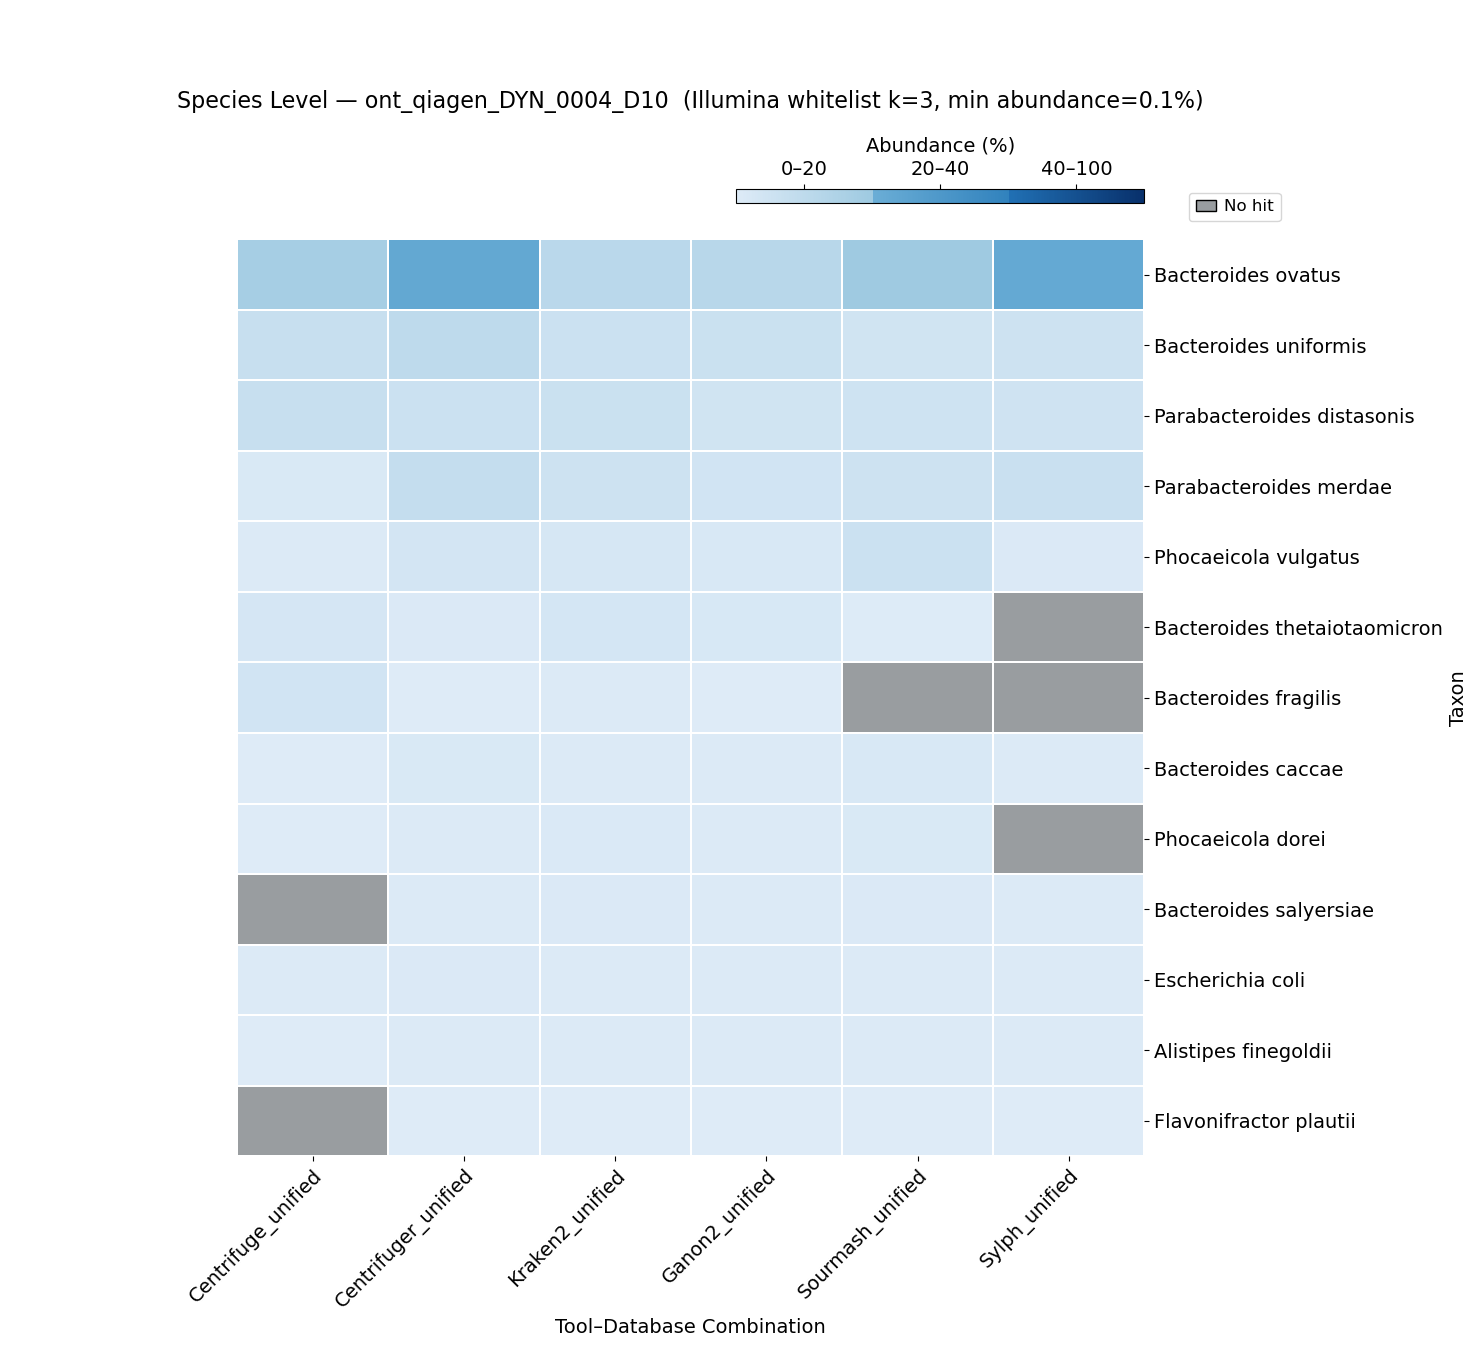

  ✓ Saved: /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/figures/ont_qiagen_DYN_0004_D10_species_abundance_heatmap_illumina_whitelist_k3_linear.png

Generating genus heatmap (7 taxa)...


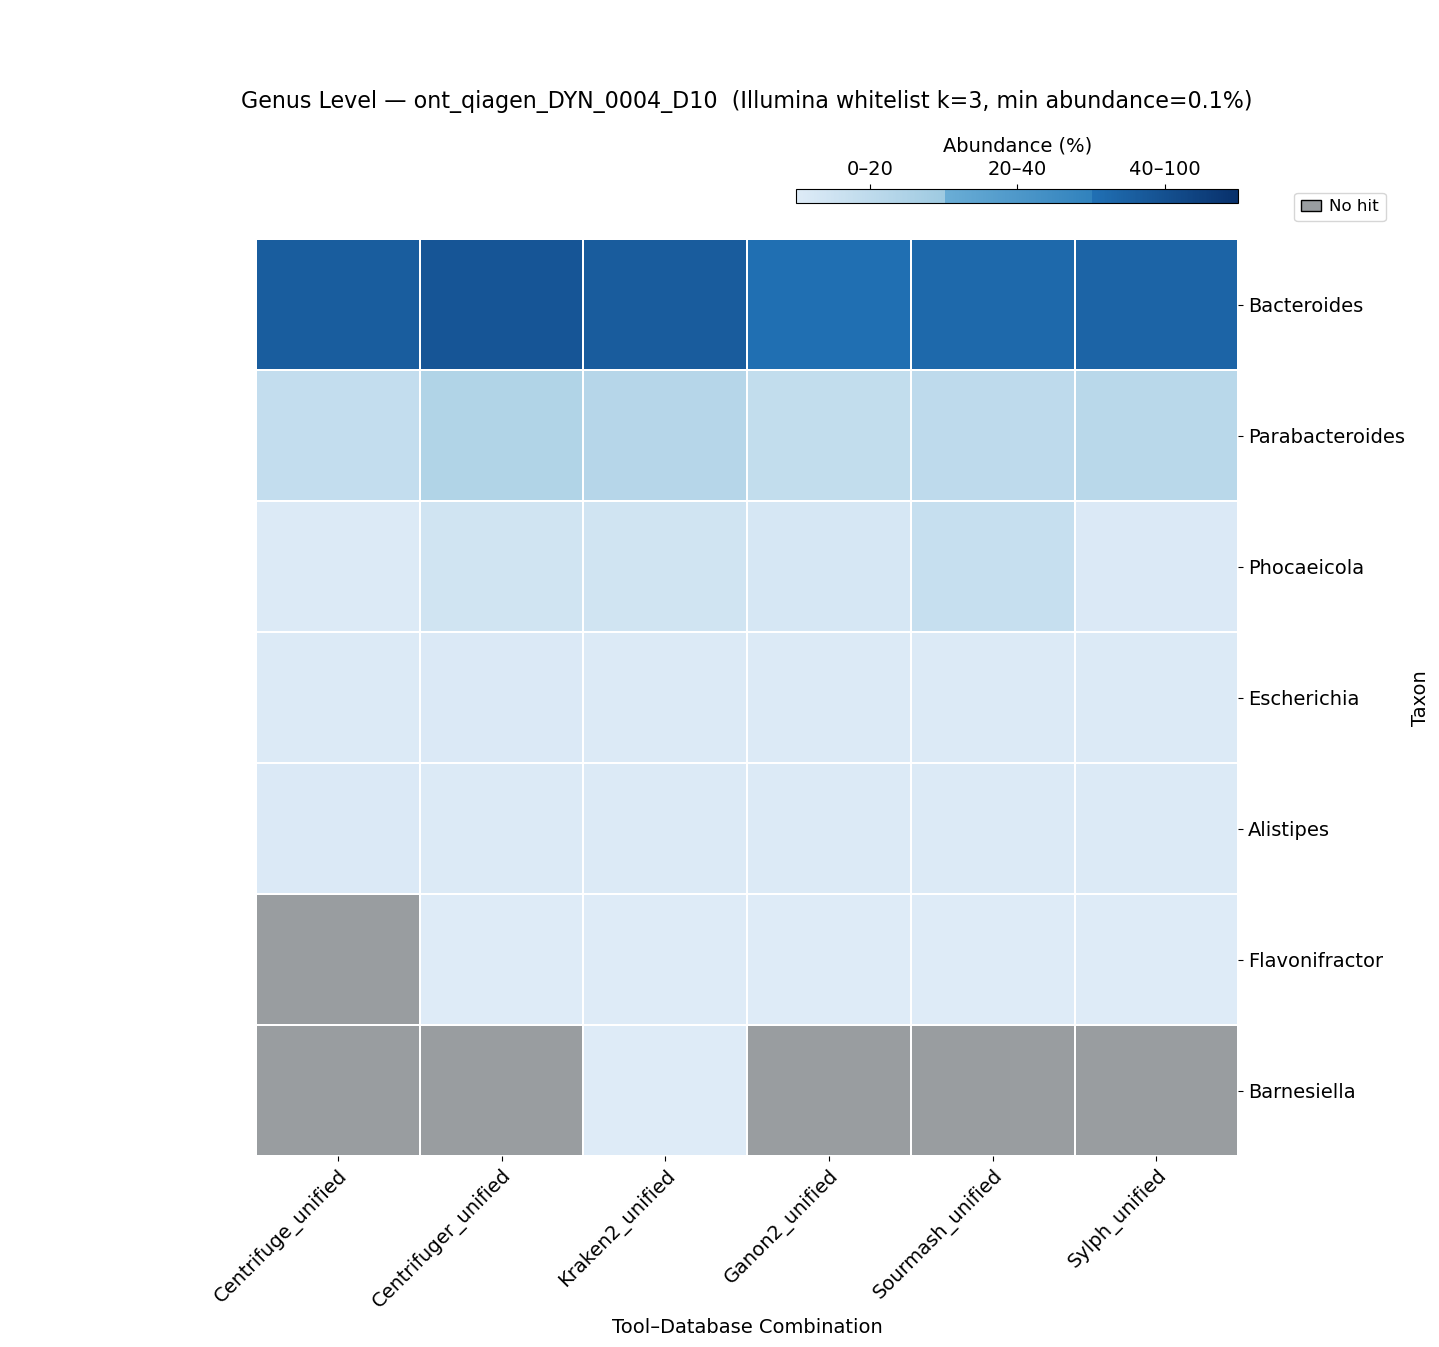

  ✓ Saved: /home/Users/pacbio_bakeoff/bakeoff/results/20260531_030023/dyn-case-heatmap/dyn_0004_d10_ont/threshold_0.1/figures/ont_qiagen_DYN_0004_D10_genus_abundance_heatmap_illumina_whitelist_k3_linear.png

Heatmaps complete.


In [16]:
# GENERATE ABUNDANCE HEATMAPS (LINEAR)
#   - name-based
#   - column order controlled by TOOL_PATHS (selected tool_db)
#   - choose which matrix you want to plot:
#       * "illu_whitelist" (Option B)  <-- recommended
#       * "ge2tools" (old behavior)

print("\n" + "="*60)
print("HEATMAPS: LINEAR SCALE")
print("="*60)

# Column order = selected tool_db plotting order
COL_ORDER = SELECTED_TOOLDBS

for rank in RANKS:
    matrix = abundance_matrices_whitelist.get(rank)
    if matrix is None or matrix.empty:
        print(f"[skip] {rank}: whitelist matrix empty")
        continue

    suffix = f"(Illumina whitelist k={ILLU_CONSENSUS_K}, min abundance={ILLU_CONSENSUS_MIN_ABUND}%)"
    out_tag = f"illumina_whitelist_k{ILLU_CONSENSUS_K}"  # min is already in OUTPUT_DIR

    n_taxa = len(matrix)
    print(f"\nGenerating {rank} heatmap ({n_taxa} taxa)...")

    # Adjust figure height based on #taxa
    fig_height = max(12, min(50, n_taxa * 0.25))

    output_path = OUTPUT_FIG / f"{DATASET_LABEL}_{rank}_abundance_heatmap_{out_tag}_linear.{FIG_FORMAT}"

    plot_abundance_heatmap_clustered(
        abundance_matrix=matrix,
        rank=rank,
        dataset_label=DATASET_LABEL,
        title_suffix=suffix,
        figsize=(14, fig_height),
        output_path=output_path,
        cluster_rows=False,
        cluster_cols=False,
        col_order=COL_ORDER,
        vmax=None,  # optionally set e.g. vmax=50 to reduce dominance saturation
    )

    print(f"  ✓ Saved: {output_path}")

print("\nHeatmaps complete.")